### Problem Statement

Analyze FreshKart’s sales data to identify key revenue and profit drivers across products, sales channels, and regions, uncover seasonal trends and outliers, and evaluate performance against sales targets and budgets. The analysis aims to generate actionable insights for optimizing pricing and promotions, improving product and regional performance, and supporting sustainable business growth.

In [158]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [159]:
sheets = pd.read_excel('/content/FreshKart Sales Analysis Sales Dataset.xlsx', sheet_name=None)

In [160]:
# Assig ataframes to each sheet

df_sales = sheets['Sales Orders']
df_regions = sheets['Regions']
df_customers = sheets['Customers']
df_state_reg = sheets['State Regions']
df_products = sheets['Products']
df_budgets = sheets['2017 Budgets']

In [161]:
df_sales.shape

(64104, 12)

In [162]:
print("df_sales.shape:",(df_sales.shape))
print("df_regions.shape:",(df_regions.shape))
print("df_customers.shape:",(df_customers.shape))
print("df_state_reg.shape:",(df_state_reg.shape))
print("df_products.shape:",(df_products.shape))
print("df_budgets.shape:",(df_budgets.shape))

df_sales.shape: (64104, 12)
df_regions.shape: (994, 15)
df_customers.shape: (175, 2)
df_state_reg.shape: (48, 3)
df_products.shape: (30, 2)
df_budgets.shape: (30, 2)


In [163]:
df_sales.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270


In [164]:
df_budgets.head(5)

,Product Name,2017 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565
2,Product 3,2642352.432
3,Product 4,2885560.824
4,Product 5,3925424.542


In [165]:
df_customers.head(5)

,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd


In [166]:
df_products.head(5)

,Index,Product Name
0,1,Product 1
1,2,Product 2
2,3,Product 3
3,4,Product 4
4,5,Product 5


In [167]:
df_regions.head(5)

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago
3,4,Dothan,Dale County/Houston County/Henry County,AL,Alabama,City,31.23370,-85.40682,334,68567,25913,42426,232166237,835468,America/Chicago
4,5,Hoover,Shelby County/Jefferson County,AL,Alabama,City,33.37695,-86.80558,205,84848,32789,77146,122016784,2553332,America/Chicago


In [168]:
df_state_reg.head(5)

,State Code,State,Region
0,AL,Alabama,South
1,AR,Arkansas,South
2,AZ,Arizona,West
3,CA,California,West
4,CO,Colorado,West


In [169]:
df_sales.isnull().sum()

,0
OrderNumber,0
OrderDate,0
Customer Name Index,0
Channel,0
Currency Code,0
Warehouse Code,0
Delivery Region Index,0
Product Description Index,0
Order Quantity,0
Unit Price,0


In [170]:
df_products.isnull().sum()

,0
Index,0
Product Name,0


In [171]:
df_state_reg.isnull().sum()

,0
State Code,0
State,0
Region,0


In [172]:
df_customers.isnull().sum()

,0
Customer Index,0
Customer Names,0


In [173]:
df_regions.isnull().sum()

,0
id,0
name,0
county,0
state_code,0
state,0
type,0
latitude,0
longitude,0
area_code,0
population,0


In [174]:
df_budgets.isnull().sum()

,0
Product Name,0
2017 Budgets,0


#### **Data Cleaning and Wrangling**

In [175]:
# Merge with Customers

df = df_sales.merge(
    df_customers,
    how='left',
    left_on='Customer Name Index',
    right_on='Customer Index'
)

In [176]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group


In [177]:
# Merge with Products

df = df.merge(
    df_products,
    how='left',
    left_on='Product Description Index',
    right_on='Index'
)

In [178]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names,Index,Product Name
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd,27,Product 27
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd,20,Product 20
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp,26,Product 26
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group,7,Product 7
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group,8,Product 8


In [179]:
# Merge with Regions

df = df.merge(
    df_regions,
    how='left',
    left_on='Delivery Region Index',
    right_on='id'
)

In [180]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,City,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,City,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,City,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,City,39.16533,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,Town,41.77524,-72.52443,959,58007,24141,63158,70972793,720300,America/New York


In [181]:
# Merge with State Regions

df = df.merge(
    df_state_reg,
    how='left',
    left_on='state_code',
    right_on='State Code'
)

In [182]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,State,Region
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,912,145674,52798,36466,268318796,13908113,America/New York,GA,Georgia,South
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Indiana,Midwest
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,California,West
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Indiana,Midwest
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,959,58007,24141,63158,70972793,720300,America/New York,CT,Connecticut,Northeast


In [183]:
# Merge with Budget

df = df.merge(
    df_budgets,
    how='left',
    left_on='Product Name',
    right_on='Product Name'
)

In [184]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,population,households,median_income,land_area,water_area,time_zone,State Code,State,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,145674,52798,36466,268318796,13908113,America/New York,GA,Georgia,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Indiana,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,79510,26020,124759,62489257,386195,America/Los Angeles,CA,California,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Indiana,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,58007,24141,63158,70972793,720300,America/New York,CT,Connecticut,Northeast,1085037.329


In [185]:
df.to_csv('files.csv')

In [186]:
#Customer index
#Index
#id
#State Code

# Clean up redundant columns

cols_to_drop = ['Customer index', 'Index', 'id', 'State Code']
df = df.drop(columns = cols_to_drop, errors='ignore')

df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,area_code,population,households,median_income,land_area,water_area,time_zone,State,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,912,145674,52798,36466,268318796,13908113,America/New York,Georgia,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Indiana,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,925,79510,26020,124759,62489257,386195,America/Los Angeles,California,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Indiana,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,959,58007,24141,63158,70972793,720300,America/New York,Connecticut,Northeast,1085037.329


In [187]:
df = df.drop(columns = 'State')

In [188]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,Northeast,1085037.329


In [189]:
# Convert all columns to lower case
df.columns = df.columns.str.lower()

df.columns.values

array(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer index',
       'customer names', 'product name', 'name', 'county', 'state_code',
       'state', 'type', 'latitude', 'longitude', 'area_code',
       'population', 'households', 'median_income', 'land_area',
       'water_area', 'time_zone', 'region', '2017 budgets'], dtype=object)

In [190]:
# Keeping import columns and Deleting irrelevant columns

cols_to_keep = [
    'ordernumber',
    'orderdate',
    'customer names',
    'channel',
    'product name',
    'order quantity',
    'unit price',
    'line total',
    'total unit cost',
    'state_code',
    'county',
    'state',
    'region',
    'latitude',
    'longitude',
    '2017 budgets'
]

In [191]:
df = df[cols_to_keep]

In [192]:
df.head(1)

,ordernumber,orderdate,customer names,channel,product name,order quantity,unit price,line total,total unit cost,state_code,county,state,region,latitude,longitude,2017 budgets
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,964940.231


In [193]:
# Rename the columns

df = df.rename(columns={
    'ordernumber': 'order_number',
    'orderdate': 'order_date',
    'customer names': 'customer_names',
    'product name': 'product_name',
    'order quantity': 'order_quantity',
    'unit price': 'unit_price',
    'line total': 'revenue',
    'cost': 'total_unit_cost',
    'state_code': 'state',
    'state': 'state_name',
    'latitude': 'lat',
    'longitude': 'long',
    '2017 budgets': 'budget'
})

df.head(1)

,order_number,order_date,customer_names,channel,product_name,order_quantity,unit_price,revenue,total unit cost,state,county,state_name,region,lat,long,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,964940.231


In [194]:
# Blank out budgets for non-2017 orders

df.loc[df['order_date'].dt.year != 2017, 'budget'] = pd.NA
df.head(1)

,order_number,order_date,customer_names,channel,product_name,order_quantity,unit_price,revenue,total unit cost,state,county,state_name,region,lat,long,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,NaN


In [195]:
df[['order_date', 'product_name', 'revenue', 'budget']].head(5)

,order_date,product_name,revenue,budget
0,2014-01-01,Product 27,14994.6,NaN
1,2014-01-01,Product 20,25868.7,NaN
2,2014-01-01,Product 26,5869.2,NaN
3,2014-01-01,Product 7,16368.1,NaN
4,2014-01-01,Product 8,18331.2,NaN


In [196]:
df[['order_date', 'product_name', 'revenue', 'budget']].tail(5)

,order_date,product_name,revenue,budget
64099,2018-02-28,Product 26,21788.4,NaN
64100,2018-02-28,Product 21,5185.8,NaN
64101,2018-02-28,Product 13,43483.0,NaN
64102,2018-02-28,Product 20,27717.9,NaN
64103,2018-02-28,Product 15,7986.4,NaN


In [197]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_number     64104 non-null  object        
 1   order_date       64104 non-null  datetime64[ns]
 2   customer_names   64104 non-null  object        
 3   channel          64104 non-null  object        
 4   product_name     64104 non-null  object        
 5   order_quantity   64104 non-null  int64         
 6   unit_price       64104 non-null  float64       
 7   revenue          64104 non-null  float64       
 8   total unit cost  64104 non-null  float64       
 9   state            64104 non-null  object        
 10  county           64104 non-null  object        
 11  state_name       64104 non-null  object        
 12  region           64104 non-null  object        
 13  lat              64104 non-null  float64       
 14  long             64104 non-null  float

In [198]:
# Filter the dataset to include only record from year 2017

df_2017 = df[df['order_date'].dt.year == 2017]

In [199]:
df.isnull().sum()

,0
order_number,0
order_date,0
customer_names,0
channel,0
product_name,0
order_quantity,0
unit_price,0
revenue,0
total unit cost,0
state,0


In [200]:
df_2017.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15263 entries, 46363 to 61625
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_number     15263 non-null  object        
 1   order_date       15263 non-null  datetime64[ns]
 2   customer_names   15263 non-null  object        
 3   channel          15263 non-null  object        
 4   product_name     15263 non-null  object        
 5   order_quantity   15263 non-null  int64         
 6   unit_price       15263 non-null  float64       
 7   revenue          15263 non-null  float64       
 8   total unit cost  15263 non-null  float64       
 9   state            15263 non-null  object        
 10  county           15263 non-null  object        
 11  state_name       15263 non-null  object        
 12  region           15263 non-null  object        
 13  lat              15263 non-null  float64       
 14  long             15263 non-null  float6

#### Feature Engineering

In [201]:
df.head()

,order_number,order_date,customer_names,channel,product_name,order_quantity,unit_price,revenue,total unit cost,state,county,state_name,region,lat,long,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,NaN
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,NaN
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,NaN
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,NaN
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,NaN


In [203]:
df['total_cost'] = df['total unit cost'] * df['order_quantity']

In [204]:
df['profit'] = df['revenue'] - df['total_cost']

df['profit_margin_pct'] = df['profit'] / df['revenue'] * 100

In [205]:
df.head(5)

,order_number,order_date,customer_names,channel,product_name,order_quantity,unit_price,revenue,total unit cost,state,county,state_name,region,lat,long,budget,total_cost,profit,profit_margin_pct
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,NaN,10946.058,4048.542,27.0
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,NaN,13969.098,11899.602,46.0
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,NaN,4108.440,1760.760,30.0
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,NaN,7201.964,9166.136,56.0
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,NaN,10082.160,8249.040,45.0


#### **EDA**

/tmp/ipykernel_2358/4281474732.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['year_month'] = df['order_date'].dt.to_period('M')


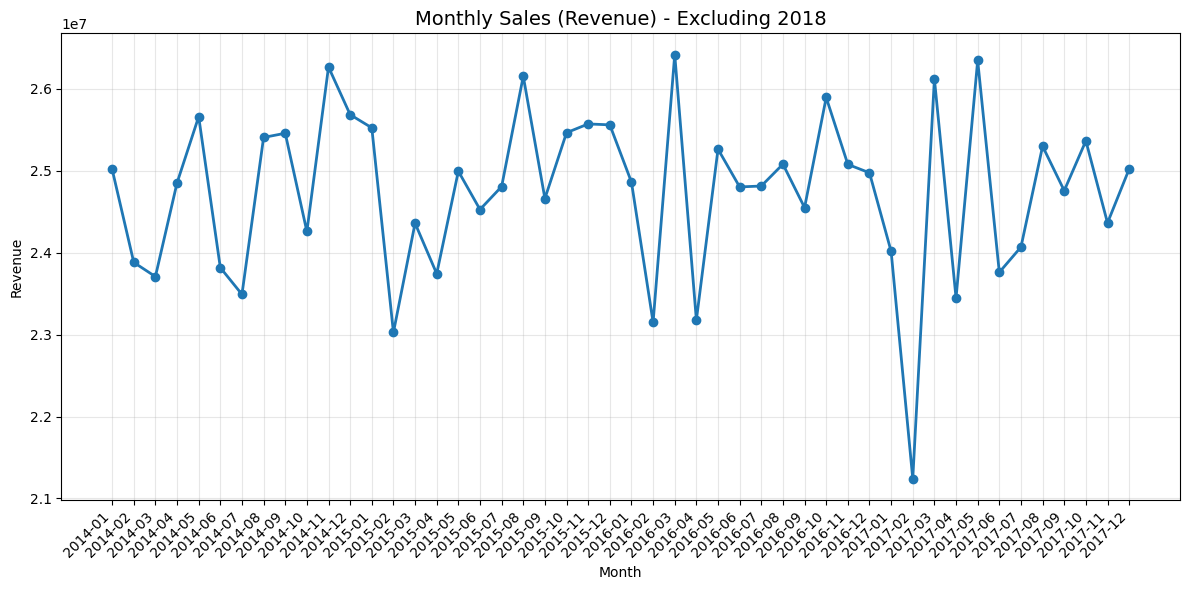

In [206]:
# Convert to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Exclude all records from 2018
df_new = df[df['order_date'].dt.year != 2018]

# Create year-month column
df_new['year_month'] = df['order_date'].dt.to_period('M')

# Aggregate monthly sales
monthly_sales = df_new.groupby('year_month')['revenue'].sum().reset_index()
monthly_sales['year_month'] = monthly_sales['year_month'].astype(str)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales['year_month'], monthly_sales['revenue'], marker='o', linewidth=2)
plt.title('Monthly Sales (Revenue) - Excluding 2018', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2358/409135567.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['order_date'] = pd.to_datetime(df['order_date'])
/tmp/ipykernel_2358/409135567.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['month'] = df_new['order_date'].dt.month


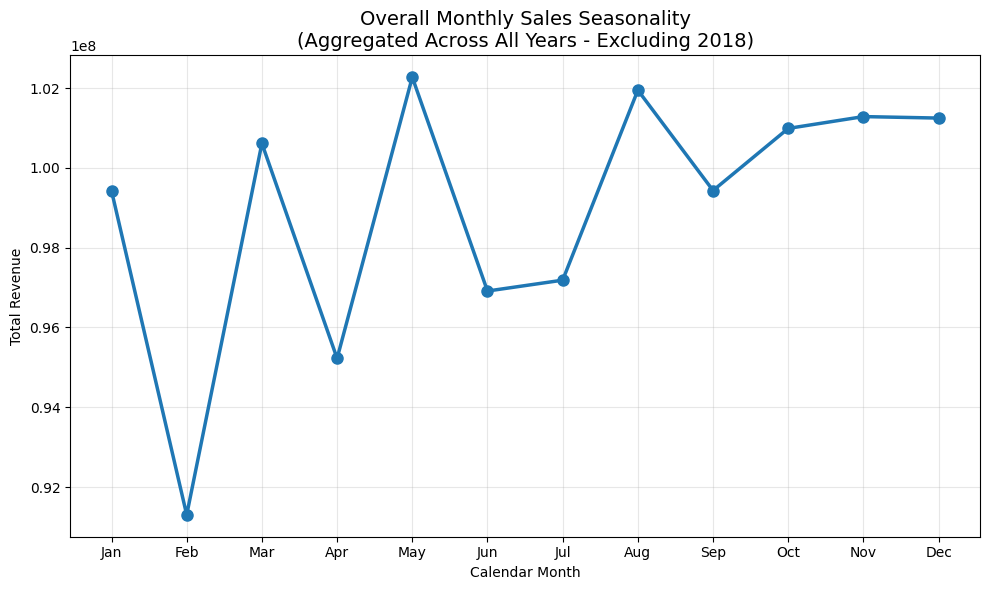

In [207]:
# Convert to datetime
df_new['order_date'] = pd.to_datetime(df['order_date'])

# Extract calendar month (1–12)
df_new['month'] = df_new['order_date'].dt.month

# Aggregate total revenue by calendar month
monthly_seasonality = df_new.groupby('month')['revenue'].sum().reset_index()

# Optional: convert month numbers to month names for better labels
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_seasonality['month_name'] = monthly_seasonality['month'].apply(lambda x: month_names[x-1])

# Plot
plt.figure(figsize=(10, 6))
plt.plot(monthly_seasonality['month_name'], monthly_seasonality['revenue'],
         marker='o', linewidth=2.5, markersize=8, color='#1f77b4')

plt.title('Overall Monthly Sales Seasonality\n(Aggregated Across All Years - Excluding 2018)', fontsize=14)
plt.xlabel('Calendar Month')
plt.ylabel('Total Revenue')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2358/1213704307.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


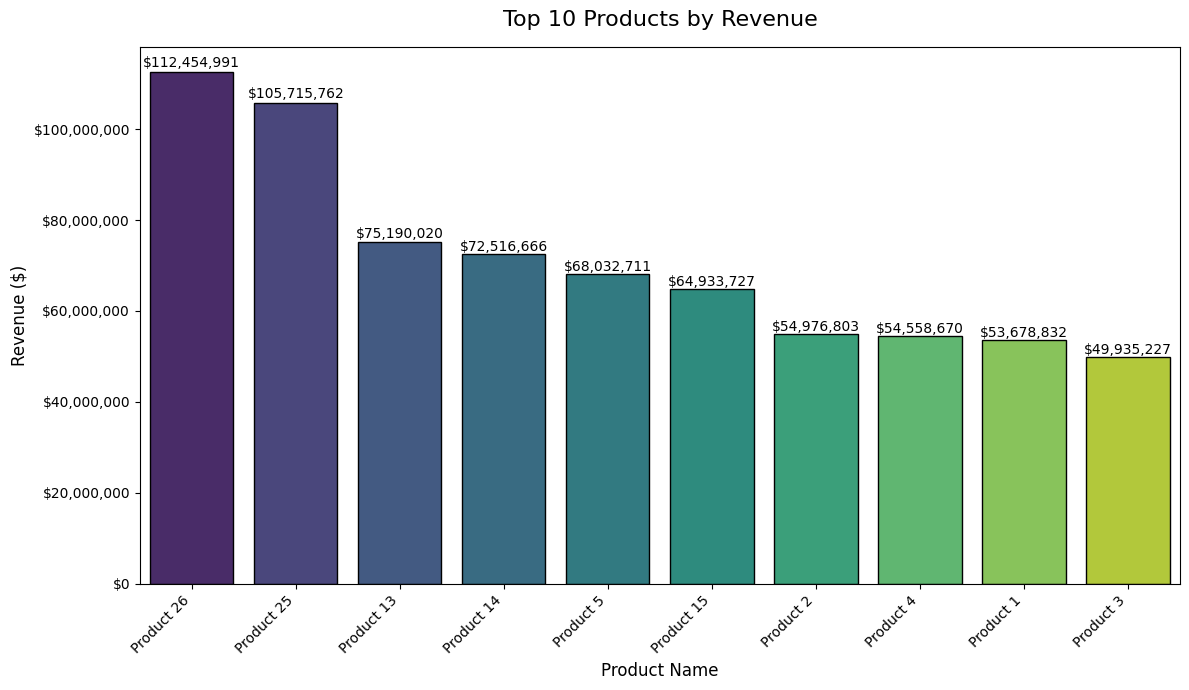

In [210]:
# Excluding 2018
# Get top 10 products by revenue
top_products = (
    df_new.groupby('product_name')['revenue']
    .sum()
    .nlargest(10)
    .reset_index()
)

# Create the chart
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_products,
    x='product_name',
    y='revenue',
    palette='viridis',
    edgecolor='black'
)

# Format Y-axis in $
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

# Add value labels on the bars
for i, value in enumerate(top_products['revenue']):
    ax.text(
        i,
        value + (value * 0.01),
        f'${value:,.0f}',
        ha='center',
        fontsize=10,
        fontweight='medium'
    )

plt.title('Top 10 Products by Revenue', fontsize=16, pad=15)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)

# Rotate product names
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2358/3761267972.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


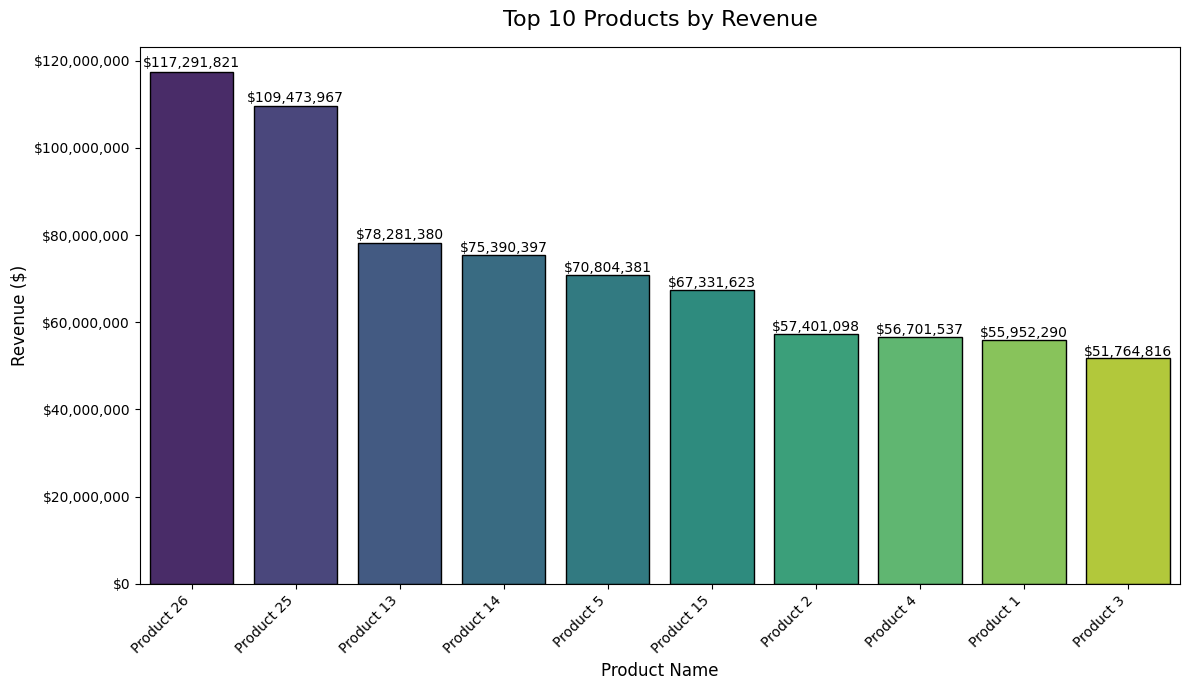

In [209]:
# Get top 10 products by revenue
top_products = (
    df.groupby('product_name')['revenue']
    .sum()
    .nlargest(10)
    .reset_index()
)

# Create the chart
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_products,
    x='product_name',
    y='revenue',
    palette='viridis',
    edgecolor='black'
)

# Format Y-axis in $
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

# Add value labels on the bars
for i, value in enumerate(top_products['revenue']):
    ax.text(
        i,
        value + (value * 0.01),
        f'${value:,.0f}',
        ha='center',
        fontsize=10,
        fontweight='medium'
    )

plt.title('Top 10 Products by Revenue', fontsize=16, pad=15)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)

# Rotate product names
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2358/2244658515.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


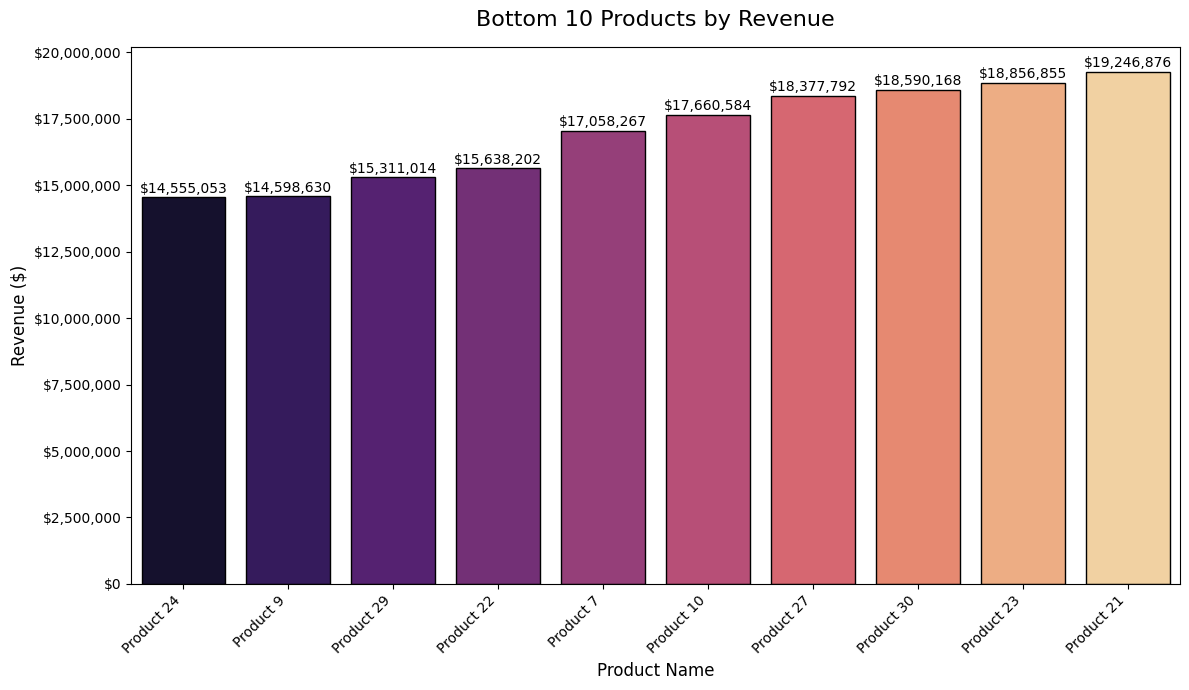

In [211]:
# Convert date
df['order_date'] = pd.to_datetime(df['order_date'])

# Get bottom 10 products by revenue
bottom_products = (
    df.groupby('product_name')['revenue']
    .sum()
    .nsmallest(10)
    .reset_index()
)

# Create the chart
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=bottom_products,
    x='product_name',
    y='revenue',
    palette='magma',
    edgecolor='black'
)

# Format Y-axis in $
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

# Add value labels on the bars
for i, value in enumerate(bottom_products['revenue']):
    ax.text(
        i,
        value + (value * 0.01),
        f'${value:,.0f}',
        ha='center',
        fontsize=10,
        fontweight='medium'
    )

plt.title('Bottom 10 Products by Revenue', fontsize=16, pad=15)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)

# Rotate product names
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

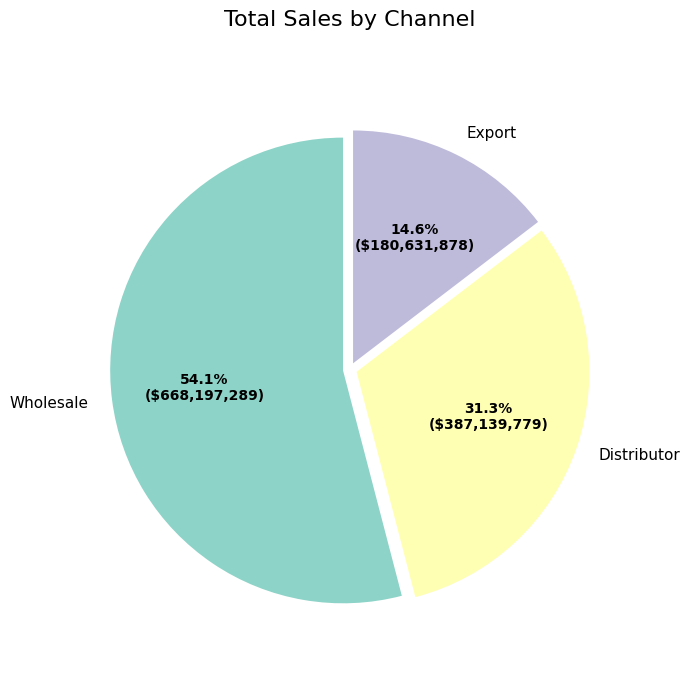

In [212]:
# Convert date
df['order_date'] = pd.to_datetime(df['order_date'])

# Aggregate total revenue by channel
channel_sales = df.groupby('channel')['revenue'].sum().sort_values(ascending=False)

# Create pie chart
plt.figure(figsize=(7,7))
colors = plt.cm.Set3.colors  # nice soft colors

wedges, texts, autotexts = plt.pie(
    channel_sales,
    labels=channel_sales.index,
    autopct=lambda pct: f'{pct:.1f}%\n(${channel_sales.sum()*pct/100:,.0f})',
    startangle=90,
    colors=colors,
    explode=[0.03] * len(channel_sales),  # slight separation
    textprops={'fontsize': 11}
)

# Style the percentage labels
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

plt.title('Total Sales by Channel', fontsize=16, pad=20)
plt.axis('equal')  # keeps the pie circular
plt.tight_layout()
plt.show()

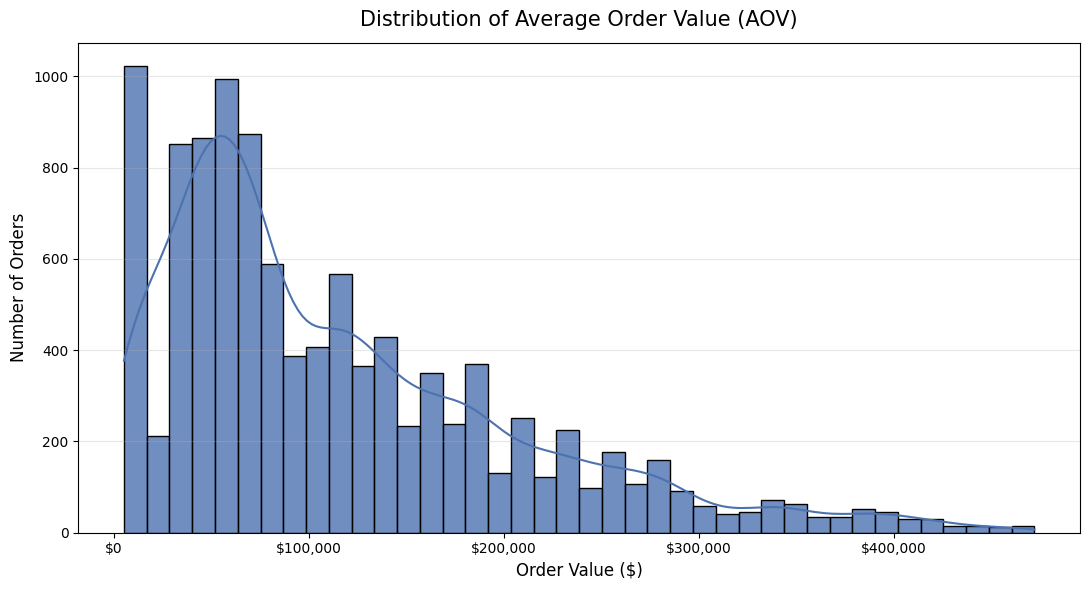

In [213]:
# Convert date
df['order_date'] = pd.to_datetime(df['order_date'])

# Calculate Order Value (total revenue per order)
order_value = df.groupby('order_number')['revenue'].sum().reset_index()
order_value.columns = ['order_number', 'order_value']

# Create histogram
plt.figure(figsize=(11, 6))
sns.histplot(
    data=order_value,
    x='order_value',
    bins=40,
    kde=True,                # adds density curve
    color='#4C72B0',
    edgecolor='black',
    alpha=0.8
)

# Format x-axis in $
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.title('Distribution of Average Order Value (AOV)', fontsize=15, pad=12)
plt.xlabel('Order Value ($)', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [96]:
# Unit Price Distribution per Product
# Top 10 States by Revenue and Order Count
# Average Profit Marging by Channel
# Top and Bottom 10 Customers by Revenue
# Customer Segmentation: Revenue vs Profit Margin
# Correlation Heatmap of Numeric Features

/tmp/ipykernel_2358/2158917923.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


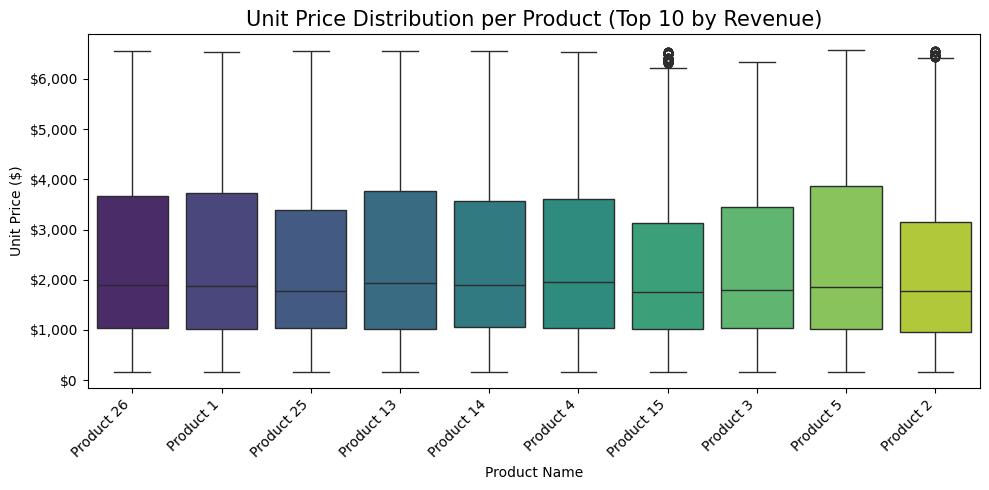

In [214]:
# Get top 10 products by revenue
top_products = (
    df.groupby('product_name')['revenue']
    .sum()
    .nlargest(10)
    .index
)

df_top = df[df['product_name'].isin(top_products)]

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df_top,
    x='product_name',
    y='unit_price',
    palette='viridis'
)

# Format Y-axis as $
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

plt.title('Unit Price Distribution per Product (Top 10 by Revenue)', fontsize=15)
plt.xlabel('Product Name')
plt.ylabel('Unit Price ($)')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

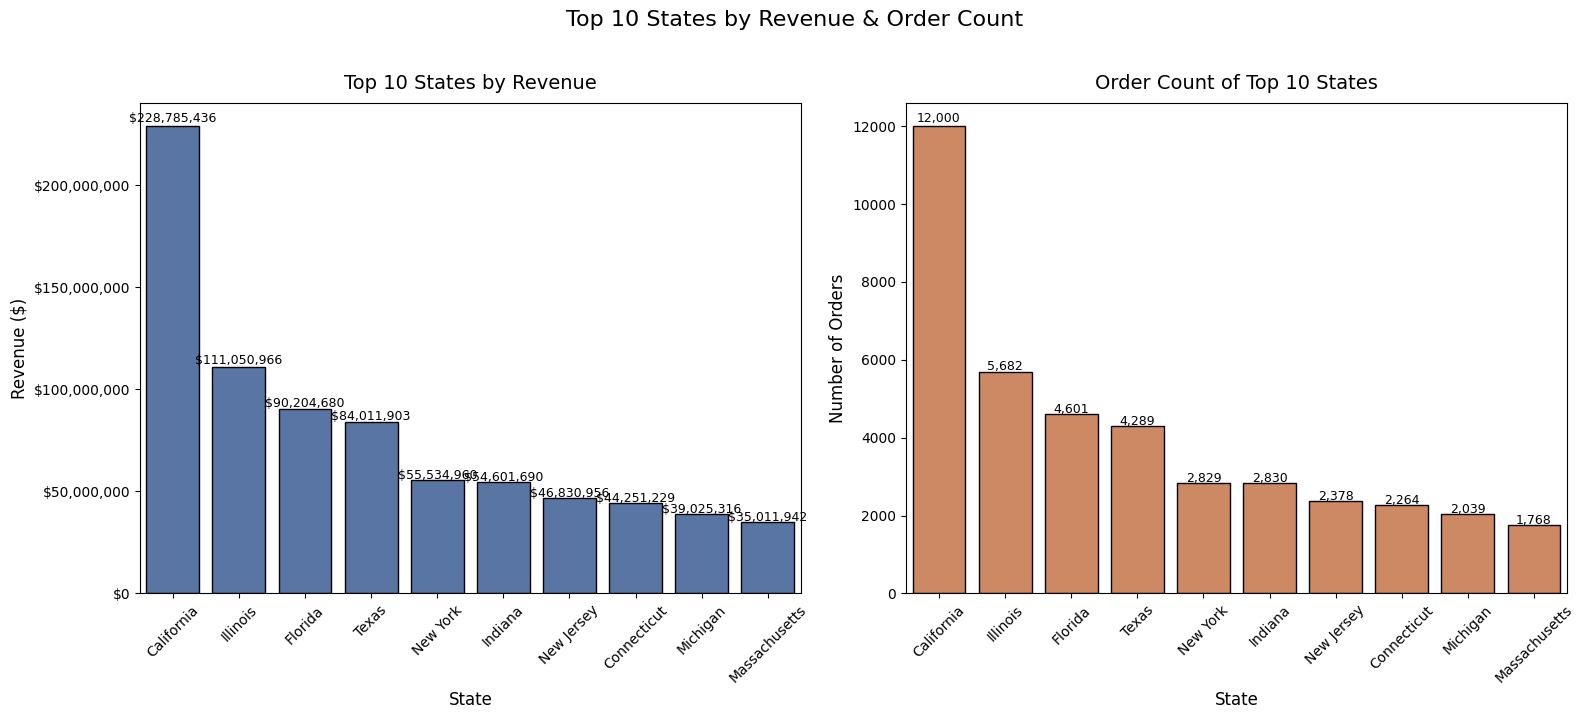

In [226]:
# Convert date
df['order_date'] = pd.to_datetime(df['order_date'])

# Aggregate Revenue and Order Count by State
state_summary = (
    df.groupby('state_name')
    .agg(
        revenue=('revenue', 'sum'),
        order_count=('order_number', 'count')
    )
    .reset_index()
)

# Get Top 10 States by Revenue
top_states = state_summary.nlargest(10, 'revenue')

# Create side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ----- Chart 1: Revenue -----
sns.barplot(
    data=top_states,
    x='state_name',
    y='revenue',
    color='#4C72B0',
    edgecolor='black',
    ax=axes[0]
)

# Format Y-axis as $
axes[0].yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

axes[0].set_title('Top 10 States by Revenue', fontsize=14, pad=10)
axes[0].set_xlabel('State', fontsize=12)
axes[0].set_ylabel('Revenue ($)', fontsize=12)

# Add value labels
for i, value in enumerate(top_states['revenue']):
    axes[0].text(
        i,
        value + (value * 0.01),
        f'${value:,.0f}',
        ha='center',
        fontsize=9
    )

# ----- Chart 2: Order Count -----
sns.barplot(
    data=top_states,
    x='state_name',
    y='order_count',
    color='#DD8452',
    edgecolor='black',
    ax=axes[1]
)

axes[1].set_title('Order Count of Top 10 States', fontsize=14, pad=10)
axes[1].set_xlabel('State', fontsize=12)
axes[1].set_ylabel('Number of Orders', fontsize=12)

# Add value labels
for i, value in enumerate(top_states['order_count']):
    axes[1].text(
        i,
        value + (value * 0.01),
        f'{value:,}',
        ha='center',
        fontsize=9
    )

# Rotate state names
axes[0].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle(
    'Top 10 States by Revenue & Order Count',
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2358/3699255910.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


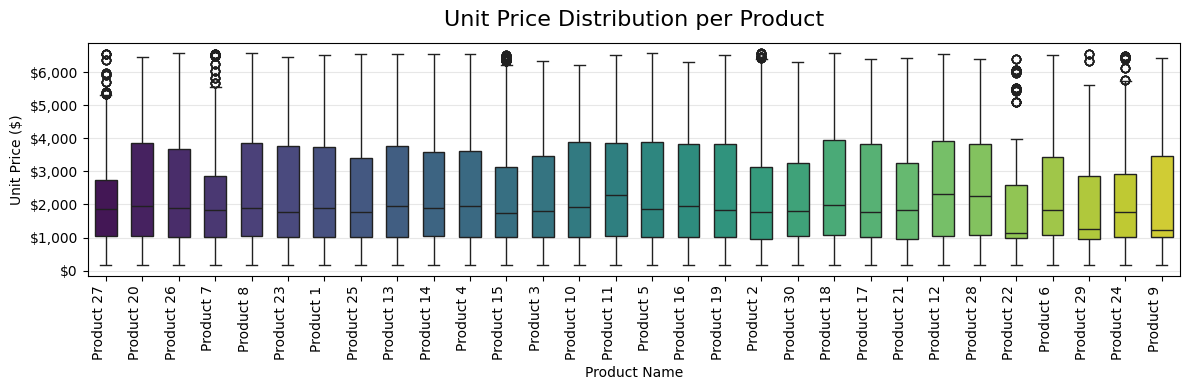

In [230]:
# Convert date
df['order_date'] = pd.to_datetime(df['order_date'])

# Create the boxplot for ALL products
plt.figure(figsize=(12, 4))
sns.boxplot(
    data=df,
    x='product_name',
    y='unit_price',
    palette='viridis',
    width=0.6
)

# Format y-axis in $
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

plt.title('Unit Price Distribution per Product', fontsize=16, pad=12)
plt.xlabel('Product Name', fontsize=10)
plt.ylabel('Unit Price ($)', fontsize=10)
plt.xticks(rotation=90, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2358/3044945873.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


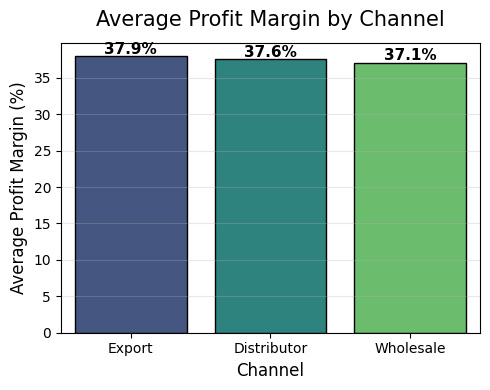

In [238]:
# Convert date
df['order_date'] = pd.to_datetime(df['order_date'])

# Calculate Average Profit Margin by Channel
channel_margin = (
    df.groupby('channel')['profit_margin_pct']
    .mean()
    .reset_index()
    .sort_values('profit_margin_pct', ascending=False)
)

# Create bar chart
plt.figure(figsize=(5, 4))
sns.barplot(
    data=channel_margin,
    x='channel',
    y='profit_margin_pct',
    palette='viridis',
    edgecolor='black'
)

# Add value labels on bars
for i, value in enumerate(channel_margin['profit_margin_pct']):
    plt.text(
        i,
        value + 0.3,
        f'{value:.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title('Average Profit Margin by Channel', fontsize=15, pad=12)
plt.xlabel('Channel', fontsize=12)
plt.ylabel('Average Profit Margin (%)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

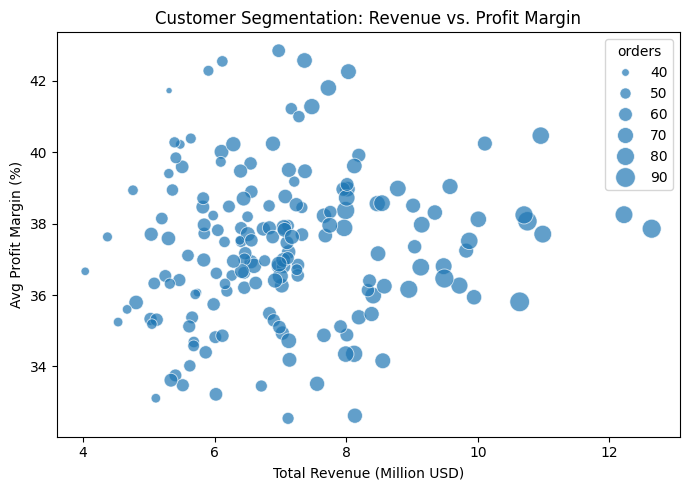

In [245]:
# Aggregate metrics per customer
cust_summary = df.groupby('customer_names').agg(
    total_revenue=('revenue', 'sum'),
    total_profit=('profit', 'sum'),
    avg_margin=('profit_margin_pct', 'mean'),
    orders=('order_number', 'nunique')
)

# Convert revenue to millions
cust_summary['total_revenue_m'] = cust_summary['total_revenue'] / 1e6

plt.figure(figsize=(7, 5))

# Bubble chart with revenue in millions
sns.scatterplot(
    data=cust_summary,
    x='total_revenue_m',        # <-- use revenue in millions
    y='avg_margin',
    size='orders',
    sizes=(20, 200),
    alpha=0.7
)

plt.title('Customer Segmentation: Revenue vs. Profit Margin')
plt.xlabel('Total Revenue (Million USD)')  # <-- updated label
plt.ylabel('Avg Profit Margin (%)')

plt.tight_layout()
plt.show()

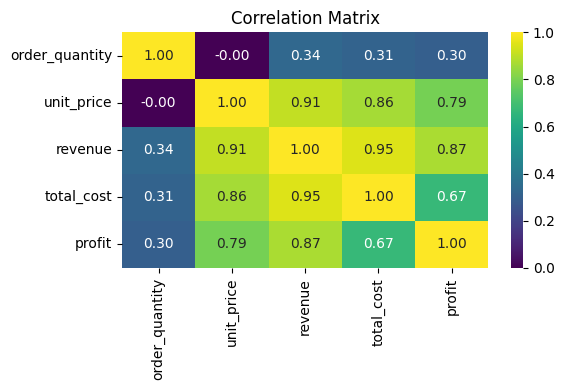

In [256]:
# List numeric columns to include in the correlation calculation
num_cols = ['order_quantity', 'unit_price', 'revenue', 'total_cost', 'profit']

# Calculate the correlation matrix for these numeric features
corr = df[num_cols].corr()

# Set the figure size for clarity
plt.figure(figsize=(6,4))

# Plot the heatmap with annotations and a viridis colormap
sns.heatmap(
    corr,           # Data: correlation matrix
    annot=True,     # Display the correlation coefficients on the heatmap
    fmt=".2f",      # Format numbers to two decimal places
    cmap='viridis'  # Color palette for the heatmap
)

# Add title for context
plt.title('Correlation Matrix')

# Adjust layout to prevent clipping
plt.tight_layout()

# Display the heatmap
plt.show()